In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv(r"titanic_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


In [3]:
df.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

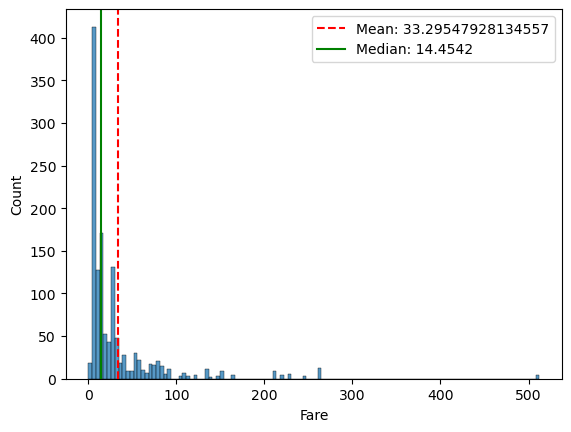

In [4]:
sns.histplot(data=df['Fare'])
mean_fare = df['Fare'].mean()
median_fare = df['Fare'].median()
plt.axvline(mean_fare, color='r', linestyle='--', label=f'Mean: {mean_fare}')
plt.axvline(median_fare, color='g', linestyle='-', label=f'Median: {median_fare}')
plt.legend()
plt.show()

In [5]:
df['Embarked'].fillna('S', inplace=True)
df['Fare'].fillna(median_fare, inplace = True)
df.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1014
Embarked          0
dtype: int64

In [6]:
df.drop('Cabin', axis=1, inplace=True)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [7]:
df.dropna(subset=['Survived'], inplace=True)
df['Age'].isnull().sum()

177

C:\Users\Tomas\anaconda3\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


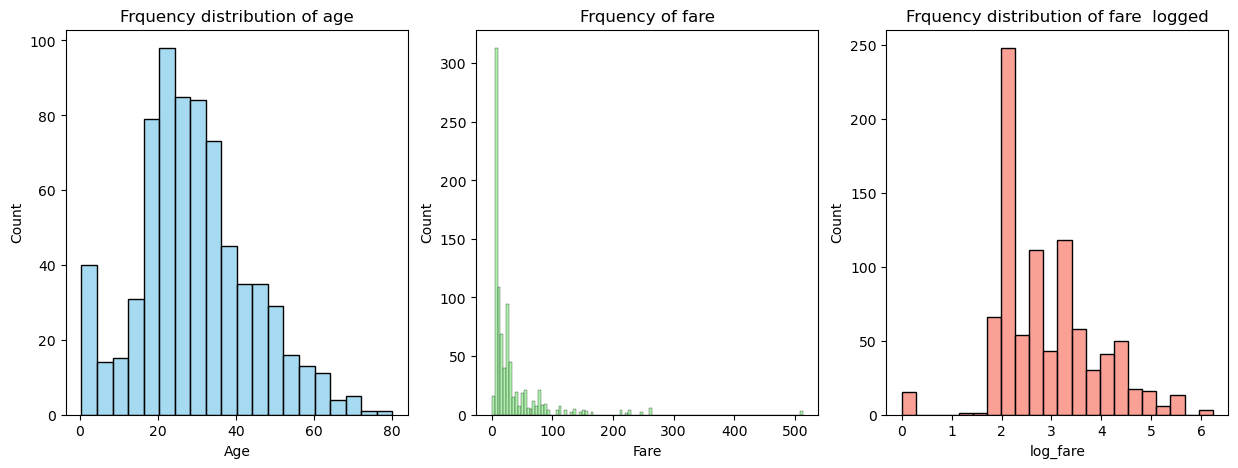

In [8]:
df['log_fare'] = np.where(df['Fare'] == 0, 0, np.log(df['Fare']))
fig, axs = plt.subplots(1, 3, figsize = (15, 5))
sns.histplot(data=df['Age'], ax= axs[0], color='skyblue')
sns.histplot(data=df['Fare'], ax= axs[1], color = 'lightgreen')
sns.histplot(data=df['log_fare'], ax= axs[2], color = 'salmon')
axs[0].set(title = 'Frquency distribution of age')
axs[1].set(title = 'Frquency of fare')
axs[2].set(title = 'Frquency distribution of fare  logged')
plt.tight_layout
fig.savefig('frq_distr_titanic.pdf')

In [9]:
df['log_fare'].isnull().sum()
np.isinf(df['log_fare']).value_counts()

log_fare
False    891
Name: count, dtype: int64

In [10]:
variables_to_standardize = ['Age', 'Fare', 'log_fare']

scaler = StandardScaler()

for var in variables_to_standardize:
    standardized_data = scaler.fit_transform(df[[var]])
    df[f'{var}_zs'] = standardized_data

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,log_fare,Age_zs,Fare_zs,log_fare_zs
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1.981001,-0.530377,-0.502445,-0.910717
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,4.266662,0.571831,0.786845,1.369616
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,2.070022,-0.254825,-0.488854,-0.821904
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,3.972177,0.365167,0.420730,1.075818
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,2.085672,0.365167,-0.486337,-0.806291


C:\Users\Tomas\anaconda3\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


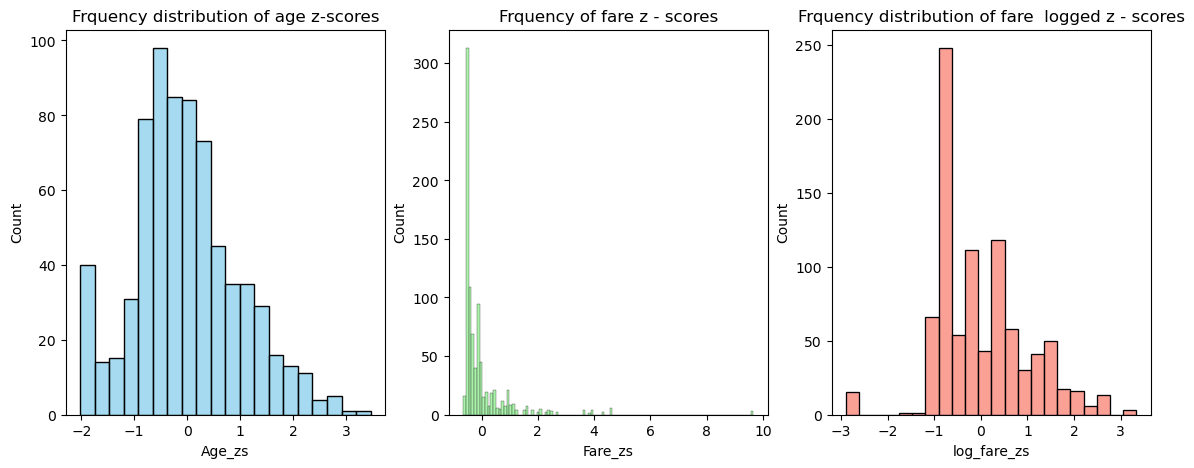

In [11]:
df['log_fare'] = np.where(df['Fare'] == 0, 0, np.log(df['Fare']))
fig, axs = plt.subplots(1, 3, figsize = (14, 5))
sns.histplot(data=df['Age_zs'], ax= axs[0], color = 'skyblue')
sns.histplot(data=df['Fare_zs'], ax= axs[1], color = 'lightgreen')
sns.histplot(data=df['log_fare_zs'], ax= axs[2], color = 'salmon')
axs[0].set(title = 'Frquency distribution of age z-scores')
axs[1].set(title = 'Frquency of fare z - scores')
axs[2].set(title = 'Frquency distribution of fare  logged z - scores')
plt.tight_layout
fig.savefig('frq_distr_z_scores_titanic.pdf')

In [12]:
knn_imputer = KNNImputer(n_neighbors=10, weights='uniform')

numeric_columns = ['Pclass', 'SibSp', 'Parch', 'Fare_zs', 'Age_zs']  
numeric_df = df[numeric_columns].copy()

imputed_data = knn_imputer.fit_transform(numeric_df)

df['Age_zs'] = imputed_data[:, numeric_columns.index('Age_zs')]

print(df['Age_zs'].isnull().sum())

0


In [13]:
df['d_Embarked'] = pd.Categorical(df['Embarked']).codes
df['d_Sex'] = pd.Categorical(df['Sex']).codes

In [14]:
X_vars = ['Pclass', 'Age_zs', 'log_fare_zs', 'd_Embarked', 'd_Sex', 'Parch', 'SibSp']
X = df[X_vars]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
accuracy_train = accuracy_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred)
recall_train = recall_score(y_train, y_train_pred)
f1_train = f1_score(y_train, y_train_pred)

y_test_pred = model.predict(X_test)
accuracy_test= accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)

print("Training Metrics:")
print(f"- Accuracy: {accuracy_train}")
print(f"- Precision: {precision_train}")
print(f"- Recall: {recall_train}")
print(f"- F1 Score: {f1_train}\n")

print("Testing Metrics:")
print(f"- Accuracy: {accuracy_test}")
print(f"- Precision: {precision_test}")
print(f"- Recall: {recall_test}")
print(f"- F1 Score: {f1_test}")

Training Metrics:
- Accuracy: 0.800561797752809
- Precision: 0.7581967213114754
- Recall: 0.6902985074626866
- F1 Score: 0.72265625

Testing Metrics:
- Accuracy: 0.8044692737430168
- Precision: 0.7746478873239436
- Recall: 0.7432432432432432
- F1 Score: 0.7586206896551724


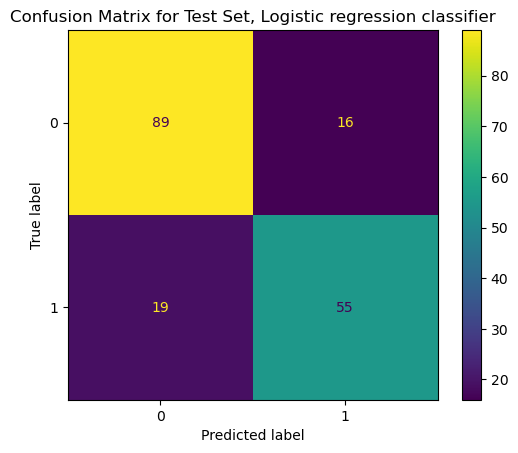

In [15]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix for Test Set, Logistic regression classifier')
plt.show()

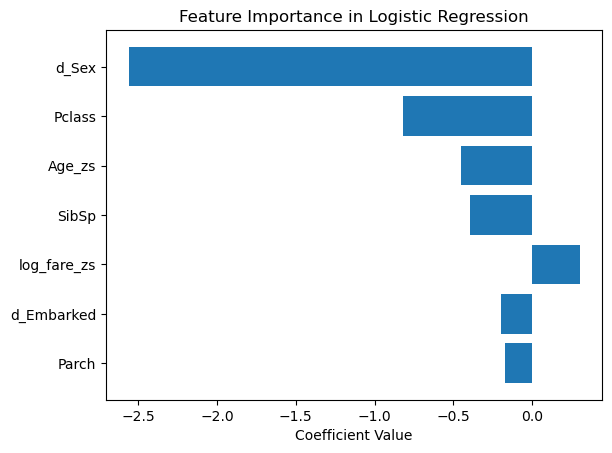

In [16]:
feature_names = X.columns
coefficients = model.coef_[0]

sorted_idx = np.argsort(abs(coefficients))

plt.barh(range(len(sorted_idx)), coefficients[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), feature_names[sorted_idx])
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Logistic Regression')
plt.show()

In [17]:
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_rf = RandomForestClassifier(random_state=42, max_depth=5)
model_rf.fit(X_train, y_train)

y_train_pred = model_rf.predict(X_train)
y_test_pred = model_rf.predict(X_test)

accuracy_train = accuracy_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred)
recall_train = recall_score(y_train, y_train_pred)
f1_train = f1_score(y_train, y_train_pred)

accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)

print("Training Metrics:")
print(f"- Accuracy: {accuracy_train}")
print(f"- Precision: {precision_train}")
print(f"- Recall: {recall_train}")
print(f"- F1 Score: {f1_train}\n")

print("Testing Metrics:")
print(f"- Accuracy: {accuracy_test}")
print(f"- Precision: {precision_test}")
print(f"- Recall: {recall_test}")
print(f"- F1 Score: {f1_test}")

Training Metrics:
- Accuracy: 0.8595505617977528
- Precision: 0.9117647058823529
- Recall: 0.6940298507462687
- F1 Score: 0.7881355932203389

Testing Metrics:
- Accuracy: 0.8100558659217877
- Precision: 0.8225806451612904
- Recall: 0.6891891891891891
- F1 Score: 0.75


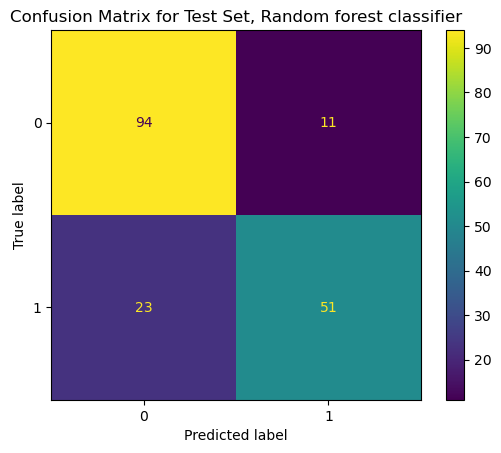

In [18]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix for Test Set, Random forest classifier')
plt.show()

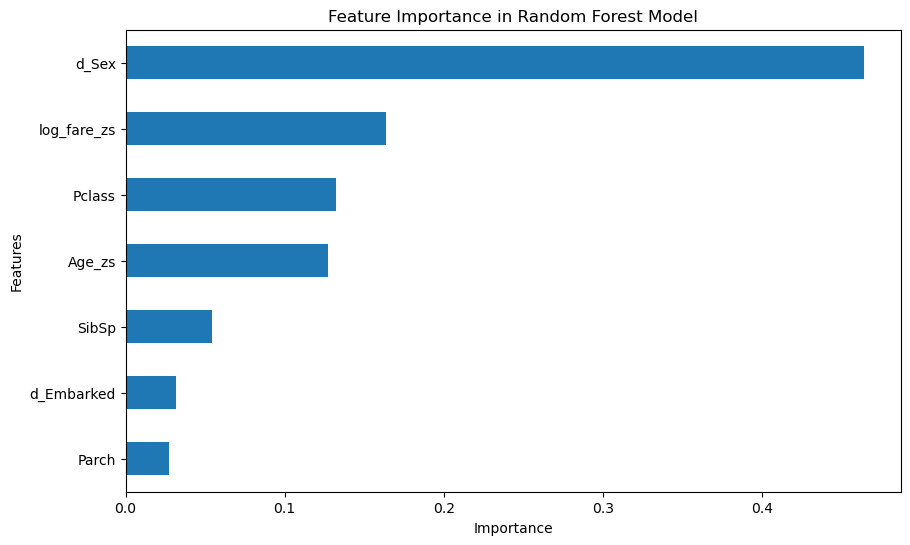

In [19]:
feature_importances = model_rf.feature_importances_
features = X_vars

feature_importance_series = pd.Series(feature_importances, index=features)

sorted_feature_importances = feature_importance_series.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
sorted_feature_importances.plot(kind='barh')
plt.title('Feature Importance in Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()